# Plot Results
Load `results.pkl` and generate all plots for the report.


## Imports & load results

In [5]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

OPTIMIZERS  = ["sgd", "adam", "lion"]
BATCH_SIZES = [32, 256, 1024]
COLORS      = {"sgd": "blue", "adam": "orange", "lion": "green"}

with open("results.pkl", "rb") as f:
    results = pickle.load(f)
print("Loaded keys:", list(results.keys()))

Loaded keys: ['sgd_bs32_warmupFalse', 'sgd_bs32_warmupTrue', 'sgd_bs256_warmupFalse', 'sgd_bs256_warmupTrue', 'sgd_bs1024_warmupFalse', 'sgd_bs1024_warmupTrue', 'adam_bs32_warmupFalse', 'adam_bs32_warmupTrue', 'adam_bs256_warmupFalse', 'adam_bs256_warmupTrue', 'adam_bs1024_warmupFalse', 'adam_bs1024_warmupTrue', 'lion_bs32_warmupFalse', 'lion_bs32_warmupTrue', 'lion_bs256_warmupFalse', 'lion_bs256_warmupTrue', 'lion_bs1024_warmupFalse', 'lion_bs1024_warmupTrue']


## Plot 1: Final val accuracy vs batch size

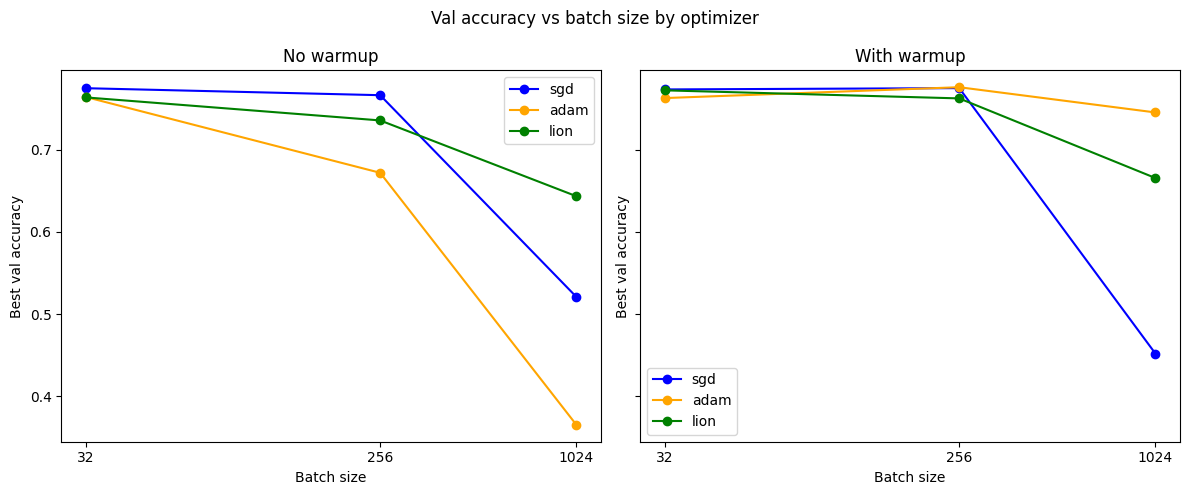

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, warmup in zip(axes, [False, True]):
    for opt in OPTIMIZERS:
        final_accs = [max(results[f"{opt}_bs{bs}_warmup{warmup}"]["val_acc"]) for bs in BATCH_SIZES]
        ax.plot(BATCH_SIZES, final_accs, marker="o", label=opt, color=COLORS[opt])
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Batch size")
    ax.set_ylabel("Best val accuracy")
    ax.set_title("With warmup" if warmup else "No warmup")
    ax.legend()
    ax.set_xticks(BATCH_SIZES)
    ax.set_xticklabels(BATCH_SIZES)

fig.suptitle("Val accuracy vs batch size by optimizer")
plt.tight_layout()
plt.savefig("plot_acc_vs_batchsize.png", dpi=150)
plt.show()

## Plot 2: Training curves — small vs large batch

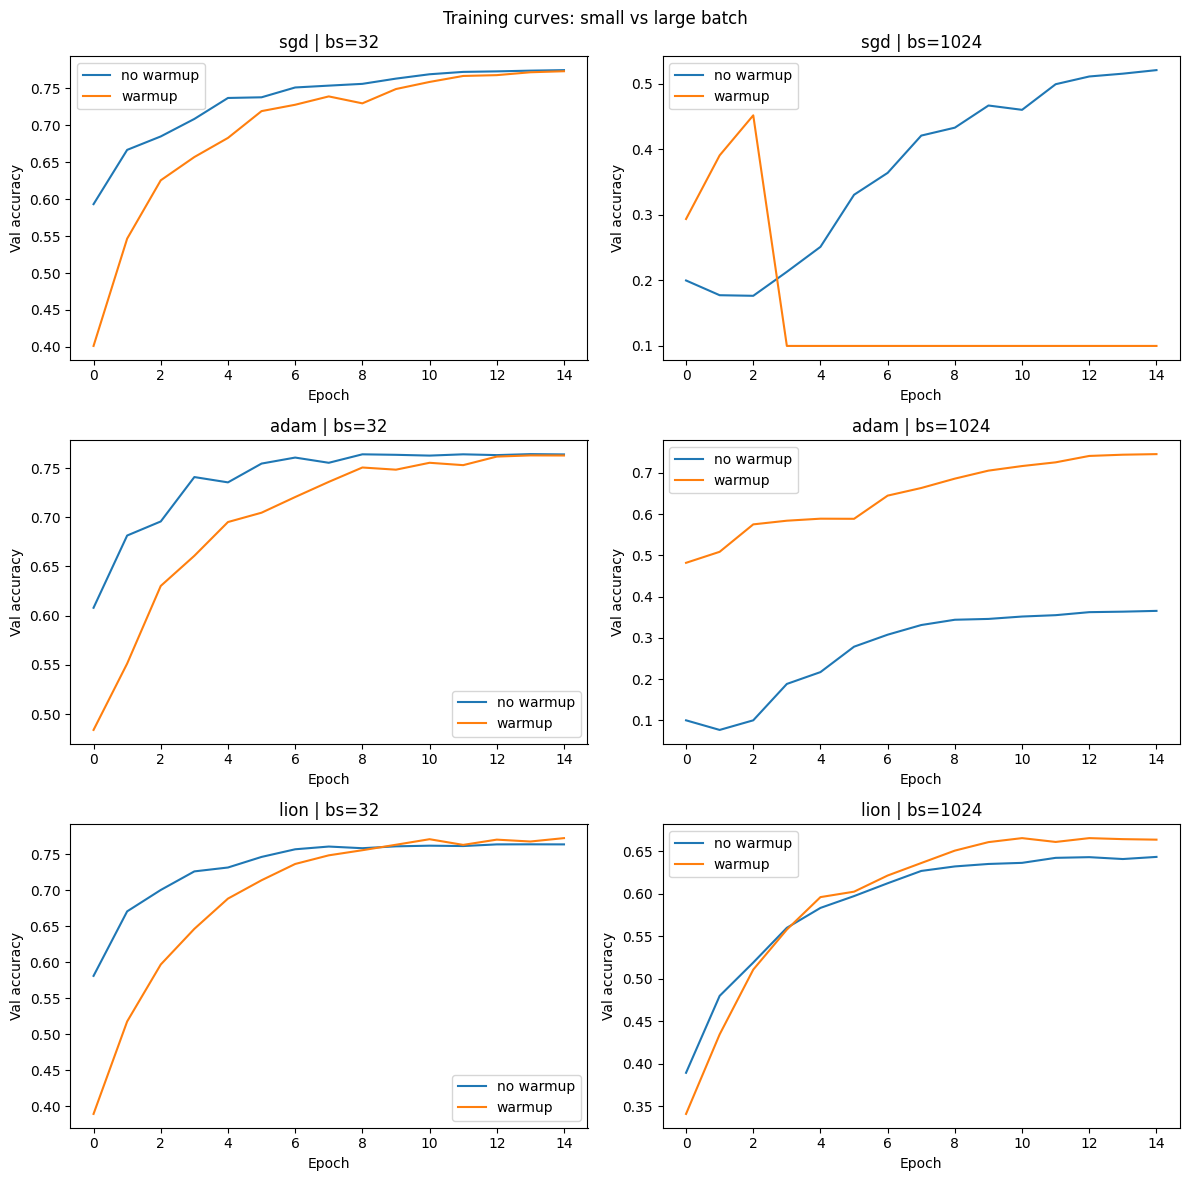

In [8]:
fig, axes = plt.subplots(len(OPTIMIZERS), 2, figsize=(12, 4 * len(OPTIMIZERS)))

for row, opt in enumerate(OPTIMIZERS):
    for col, bs in enumerate([32, 1024]):
        ax = axes[row][col]
        for warmup in [False, True]:
            key   = f"{opt}_bs{bs}_warmup{warmup}"
            label = "warmup" if warmup else "no warmup"
            ax.plot(results[key]["val_acc"], label=label)
        ax.set_title(f"{opt} | bs={bs}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Val accuracy")
        ax.legend()

fig.suptitle("Training curves: small vs large batch")
plt.tight_layout()
plt.savefig("plot_curves.png", dpi=150)
plt.show()

NOTE: We see accuracy crash for SGD at large batch size. Though I think it is training instability / divergence. It got a too large LR due to the warmup, and therefore diverged. An interesting way to visualize advantage with optimizers like Adam that adapt the learning rate depending on gradients.

NOTE: For other methods validation accuracy keep rising, so probably hasn't converged. So probably need to test with more epochs

## Plot 3: Warmup benefit per optimizer and batch size

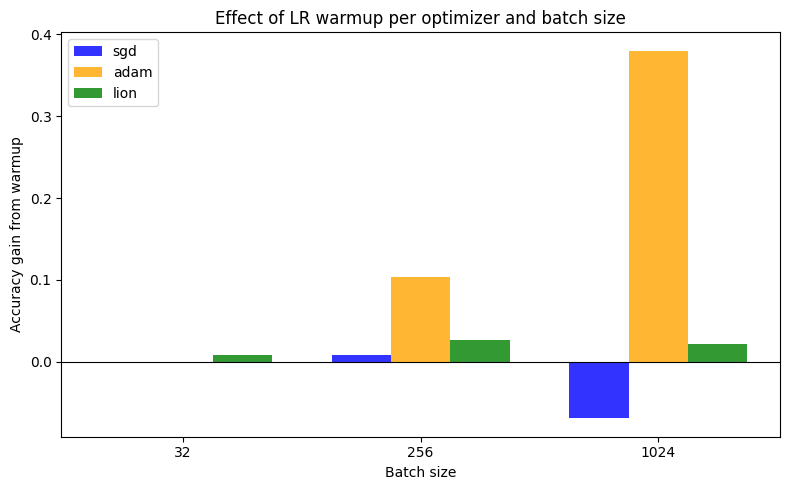

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x     = np.arange(len(BATCH_SIZES))
width = 0.25

for i, opt in enumerate(OPTIMIZERS):
    diffs = [
        max(results[f"{opt}_bs{bs}_warmupTrue"]["val_acc"]) -
        max(results[f"{opt}_bs{bs}_warmupFalse"]["val_acc"])
        for bs in BATCH_SIZES
    ]
    ax.bar(x + i * width, diffs, width, label=opt, color=COLORS[opt], alpha=0.8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(BATCH_SIZES)
ax.set_xlabel("Batch size")
ax.set_ylabel("Accuracy gain from warmup")
ax.set_title("Effect of LR warmup per optimizer and batch size")
ax.legend()
plt.tight_layout()
plt.savefig("plot_warmup_effect.png", dpi=150)
plt.show()

NOTE: We see negative gain from warmup for SGD at large batch size. Though I think it is training instability / divergence. It got a too large LR due to the warmup, and therefore diverged. An interesting way to visualize advantage with optimizers like Adam that adapt the learning rate depending on gradients.